# Information frictions in the sequence space

This notebook shows how to nest deviations from full-information rational expectations (FIRE) directly in the sequence space, following "Micro Jumps, Macro Humps". The key idea: take a FIRE Jacobian $M$ and an **expectations matrix** $E$ (whose column $s$ holds beliefs over time about a date-$s$ shock), and combine them into a *behavioral* Jacobian via

$$M^{\text{beh}}_{t,s} = \sum_{\tau=0}^{\min(t,s)} \left(E_{\tau,s} - E_{\tau-1,s}\right) M_{t-\tau,\,s-\tau}.$$

Because this is a cheap matrix operation applied to Jacobians, the same machinery works for RA *and* HA blocks. We build $E$ matrices for sticky expectations, dispersed information, cognitive discounting, and level-$k$ thinking, and apply them to a HANK monetary policy experiment.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
import json
import sequence_jacobian as sj

In [2]:
plt.rcParams.update({'font.size': 10, 'font.family': 'serif', 'figure.figsize': (6, 3)})
plt.rcParams.update({'text.usetex': True, 'font.serif': 'Palatino'})

In [3]:
from calibration import make_calibration

calibration, e = make_calibration(lowA=False)
calibration |= {'e': e, 'Z': 0.7}

def income(e, Z):
    y = Z * e
    return y

hh = sj.hetblocks.hh_sim.hh.add_hetinputs([income]).remap({'r': 'rp'})
calibration['rp'] = calibration['r']

In [4]:
# Compute steady state
ss = hh.steady_state(calibration)

In [5]:
# time horizon used here
T = 400

## Set up other blocks

Set up the fiscal and market clearing blocks. The fiscal block runs a debt rule: taxes `T` respond to the interest cost of outstanding debt with feedback `psi`, which keeps debt `B` stationary while delivering after-tax income `Z = Y - T`. This endogenous tax response is exactly the `dT` term that will enter the IKC below.

In [6]:
@sj.solved(unknowns={'B': (-10, 10)}, targets=['budget'])
def fiscal(rp, G, Y, psi, B):
    # B = (1 + rp.ss) * B_ss / (1 + rp(+1))
    T_ss = rp.ss * B.ss + G.ss  # steady state tax
    T = T_ss + psi * ((1 + rp) * B(-1) - (1 + rp.ss) * B.ss) 
    # T = T_ss + psi * (B(-1) - B_ss)  # alternative without interest rate
    budget = B - (1 + rp) * B(-1) + T - G  # budget constraint
    Z = Y - T  # after tax income
    deficit = G - T
    return T, Z, deficit, budget

@sj.simple
def mkt_clearing(A, B, Y, C, G):
    asset_mkt = A - B
    goods_mkt = Y - C - G
    return asset_mkt, goods_mkt

Set up the model and run the steady state.

In [7]:
ha = sj.create_model([fiscal, hh, mkt_clearing], name="Simple HA Model")

In [8]:
calibration.update({'G': 1 - ss['C'],
                    'Y': 1,
                    'psi': 0.1,
                    'B': ss['A']})
ss = ha.steady_state(calibration, dissolve=['fiscal'])

Check that asset market, goods market, and the government budget all clear in steady state.

In [9]:
ss['asset_mkt'], ss['goods_mkt'], ss['budget']

(1.1330131787445907e-05, -4.5304744333840574e-07, 1.4988010832439613e-15)

## Set up functions to make monetary plots

`plot_MP` solves and plots the general-equilibrium output response to a monetary policy shock under a given (possibly behavioral) Jacobian pair. It solves the intertemporal Keynesian cross $d\mathbf{Y} = M^r d\mathbf{r} - M\, d\mathbf{T} + M\, d\mathbf{Y}$ for $d\mathbf{Y} = (I - M)^{-1}(M^r d\mathbf{r} - M\, d\mathbf{T})$, where the endogenous tax path $d\mathbf{T}$ comes from the fiscal block. The two panels contrast a contemporaneous ($t=0$) rate cut with an anticipated ($t=T^{fg}$) rate cut, the classic forward-guidance comparison.

In [10]:
def plot_MP(Mr_list, M_list, filename='test', legend_list=None, color_list=['black','red','blue','brown','orange', 'green'],
            style_list=['solid']*6, rho=0.80, Tplot=70, Tfg=40):
    # For each (Mr, M) pair, solve the IKC dY = (I - M)^(-1) (Mr dr - M dT) and plot dY.
    # Left panel: rate cut realized at t=0; right panel: same cut anticipated at t=Tfg.
    n = len(Mr_list)
    assert n == len(M_list)
    
    assert n <= 6  # need to add more colors and styles if larger
    
    if legend_list is None:
        legend_list = [''] * n
    else:
        assert len(legend_list) == n
        
    # Rate-cut paths: drp1 is realized at t=0, drp2 is the same path shifted to t=Tfg (forward guidance)
    dr = - 0.25 * rho ** np.arange(T)
    drp1, drp2 = np.zeros_like(dr), np.zeros_like(dr)
    drp1[1:] = dr[:-1]
    drp2[Tfg:] = dr[:T-Tfg]

    # Plot
    plt.figure(figsize=(8.3, 4))
    plt.subplot(1,2,1)
    for i in range(n):
        tax_irf = fiscal.impulse_linear(ss, inputs={'rp': drp1})['T']  # endogenous dT from the debt rule
        irf = np.linalg.solve(np.eye(T) - M_list[i], Mr_list[i] @ drp1 - M_list[i] @ tax_irf)  # GE output response
        plt.plot(irf[:Tplot], color=color_list[i], label=legend_list[i], linestyle=style_list[i])
    plt.axhline(y=0, color='#808080', linestyle=':')
    plt.xlabel('Quarter')
    plt.ylabel('\% of output')
    plt.title('Response to $t=0$ rate cut')
    plt.subplot(1,2,2)
    for i in range(n):
        tax_irf = fiscal.impulse_linear(ss, inputs={'rp': drp2})['T']
        irf = np.linalg.solve(np.eye(T) - M_list[i], Mr_list[i] @ drp2 - M_list[i] @ tax_irf)
        plt.plot(irf[:Tplot], color=color_list[i], label=legend_list[i], linestyle=style_list[i])
    plt.axhline(y=0, color='#808080', linestyle=':')
    plt.xlabel('Quarter')
    plt.title('Response to $t=' + str(Tfg) + '$ rate cut')
    plt.tight_layout()
    plt.legend(frameon=False)
    plt.savefig('figures/lecture13_' + filename + '.pdf', transparent=True)

## FIRE benchmark

First the full-information rational-expectations benchmark: extract the household intertemporal MPC matrix `M_ha` ($dC/dZ$) and the interest-rate Jacobian `Mr_ha` ($dC/dr^p$), then plot the GE response with no information friction. Every behavioral case below is a manipulation of these two matrices.

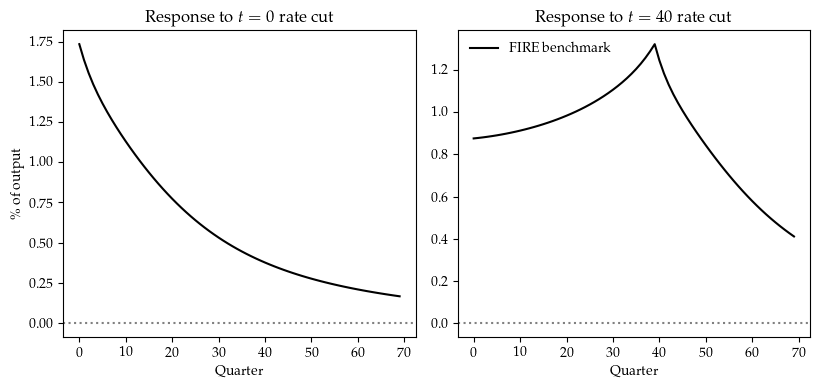

In [11]:
J = hh.jacobian(ss, inputs=['rp', 'Z'], outputs=['C', 'A'], T=T)
M_ha = J['C', 'Z']
Mr_ha = J['C', 'rp']

plot_MP([Mr_ha], [M_ha], filename='fire_benchmark', legend_list=['FIRE benchmark'])

(Optional cross-check: solving the full model with `solve_impulse_linear` gives the same FIRE response.)

In [12]:
# irf = ha.solve_impulse_linear(ss, unknowns=['Y'], targets=['goods_mkt'], inputs={'rp': -0.25 * 0.8**np.arange(T)}) 

# Set up Jacobian manipulation functions

This function implements the central formula of the lecture: it manipulates a FIRE Jacobian `M` with an expectations matrix `E` to produce the behavioral Jacobian `M_beh`,

$$M^{\text{beh}}_{t,s} = \sum_{\tau=0}^{\min(t,s)} \left(E_{\tau,s} - E_{\tau-1,s}\right) M_{t-\tau,\,s-\tau}.$$

Each $E_{\tau,s} - E_{\tau-1,s}$ is the *news* arriving at date $\tau$ about a date-$s$ shock; after that news, agents behave exactly as under an unanticipated shock, which is the shifted FIRE response $M_{t-\tau,\,s-\tau}$.

In [13]:
from numba import njit
@njit
def manipulate_separable(M, E):
    """ Here, E is the expectation matrix, M is the FIRE Jacobian """
    T, m = M.shape
    assert T == m
    assert E.shape == (T, T)
    
    M_beh = np.empty_like(M)
    for t in range(T):
        for s in range(T):
            summand = 0
            for tau in range(min(s,t)+1):
                if tau > 0:
                    # news at date tau about shock s, times the shifted unanticipated response
                    summand += (E[tau, s] - E[tau-1, s]) * M[t - tau, s - tau]
                else:
                    # tau = 0: initial expectation E[0, s] (no preceding row to difference against)
                    summand += E[tau, s] * M[t - tau, s - tau]
            M_beh[t, s] = summand
    return M_beh

Two sanity checks. With $E$ all ones (full information, every shock fully anticipated from the start) the behavioral Jacobian must equal the FIRE Jacobian. With $E$ lower-triangular of ones (full myopia: agents only learn about a shock when it hits) every column should become the unanticipated date-0 response shifted down the diagonal.

In [14]:
# test with unit expectations matrix
M = np.random.rand(10, 10)
E = np.ones((10, 10))
manipulate_separable(M, E)
assert np.allclose(manipulate_separable(M, E), M)

# test with upper triangular expectations matrix
M = np.random.rand(10, 10)
E = np.tril(np.ones((10, 10)))
Mbeh = manipulate_separable(M, E)
for i in range(10):
    assert np.allclose(Mbeh[i:, i], M[:10-i, 0])

### Sticky expectations
Both checks pass, so the manipulation is correct. Now we write the expectations matrices for each friction.

**Sticky expectations** (Mankiw-Reis 2002, Carroll et al. 2020): each period a household updates its information with probability $1-\theta$. After $\tau$ periods, the probability of having updated at least once is $1 - \theta^{\tau+1}$, which is the column of `E`.

In [15]:
def E_sticky_exp(theta, T=T, sticky_info=False):
    col = 1 - theta**(1 + np.arange(T))      # prob. of having updated within tau periods
    E = np.tile(col[:, np.newaxis], (1, T))  # same column repeated (dampening vs initial period)
    if sticky_info:
        return E
    else:
        # below the diagonal a shock is already realized, so expectations = 1 (full info)
        E = np.triu(E, +1) + np.tril(np.ones((T, T)))
        return E

Simple test:

In [16]:
E_sticky_exp(0.5)[:5, :5]

array([[1.    , 0.5   , 0.5   , 0.5   , 0.5   ],
       [1.    , 1.    , 0.75  , 0.75  , 0.75  ],
       [1.    , 1.    , 1.    , 0.875 , 0.875 ],
       [1.    , 1.    , 1.    , 1.    , 0.9375],
       [1.    , 1.    , 1.    , 1.    , 1.    ]])

### Dispersed information

**Dispersed information** (noisy signals): each period $j$ agents receive a signal of precision $\tau_j$ (relative to the prior precision $\tau_\epsilon$). After accumulating signals, the Kalman weight on the truth is $\sum_j \tau_j / (\sum_j \tau_j + 1)$, which forms the column of `E`.

In [17]:
def E_dispersed_exog(taus, T=T, sticky_info=False):
    assert taus.shape == (T,)  # these are tau_j / tau_eps
    col = np.cumsum(taus) / (np.cumsum(taus) + 1)  # Bayesian weight on truth after accumulating signals
    E = np.tile(col[:, np.newaxis], (1, T))
    if sticky_info:
        return E
    else:
        E = np.triu(E, +1) + np.tril(np.ones((T, T)))  # full info once the shock has realized
        return E

In [18]:
E_dispersed_exog(np.ones(T)*1)[:5, :5]

array([[1.        , 0.5       , 0.5       , 0.5       , 0.5       ],
       [1.        , 1.        , 0.66666667, 0.66666667, 0.66666667],
       [1.        , 1.        , 1.        , 0.75      , 0.75      ],
       [1.        , 1.        , 1.        , 1.        , 0.8       ],
       [1.        , 1.        , 1.        , 1.        , 1.        ]])

### Cognitive discounting

**Cognitive discounting** (Gabaix 2020): agents respond to a shock $h$ periods out as if its size were dampened by $\theta^h$. Crucially the dampening is relative to the *diagonal* (the current period), not to the initial period as in sticky information, so column $s$ of `E` reads $1, \theta, \theta^2, \dots$ starting from the diagonal.

In [19]:
def E_cog_disc(theta, T=T):
    E = np.ones((T, T))
    for t in range(T):
        E[t,t:] = theta**np.arange(T-t)   # decay theta^h going forward from the diagonal
    return E

In [20]:
E_cog_disc(0.5)[:5, :5]

array([[1.    , 0.5   , 0.25  , 0.125 , 0.0625],
       [1.    , 1.    , 0.5   , 0.25  , 0.125 ],
       [1.    , 1.    , 1.    , 0.5   , 0.25  ],
       [1.    , 1.    , 1.    , 1.    , 0.5   ],
       [1.    , 1.    , 1.    , 1.    , 1.    ]])

In [21]:
# theta=0 cognitive discounting = full myopia = sticky expectations with theta=1
assert np.allclose(E_cog_disc(0), E_sticky_exp(1))

### Level $k$ thinking

**Level-$k$ thinking** (Farhi-Werning 2019, the first paper to combine HANK with non-FIRE). At level 1 everyone believes others keep output at steady state (the myopic case, $E$ from cognitive discounting with $\theta=0$). At level $k$ everyone believes others reason at level $k-1$. The recursion $dY^{(k+1)} = M^r d\mathbf{r} + M\, dY^{(k)} + M^{(1)}(dY^{(k+1)} - dY^{(k)})$ leads to an *effective* Jacobian $M^{(k)}$ at each level; `level_k` returns these effective Jacobians so they can be plugged into the same IKC solver.

In [22]:
def level_k(M, k_max=1, T=T):
    # Level 1 = myopia: behavioral Jacobian M1 and its GE solution operator G1 = (I - M1)^(-1)
    M1 = manipulate_separable(M, E_cog_disc(0, T=T))
    G1 = np.linalg.inv(np.eye(T) - M1)
    
    # Iterate up the levels, accumulating the effective Jacobian M_effective that reproduces
    # the level-(k+1) GE response when fed through the standard (I - M)^(-1) IKC solver
    G_list = [G1]
    M_list = [M1]
    for i in range(k_max-1):
        G_k = G_list[-1]
        partialY_kplus1 = np.eye(T) + (M - M1) @ G_k                       # dY^(k+1) sensitivity
        G_kplus1 =  np.linalg.solve(np.eye(T) - M1, partialY_kplus1)       # level-(k+1) solution operator
        M_effective = np.eye(T) - np.linalg.solve(partialY_kplus1, np.eye(T) - M1)
        G_list.append(G_kplus1)
        M_list.append(M_effective)
    M_list.reverse()  # return highest level first, matching the FIRE-to-low-k legend order
    return M_list

# Applying information frictions to monetary policy in HANK

With the FIRE Jacobians (`M_ha`, `Mr_ha`) and the expectations matrices in hand, every result below is just: build the behavioral Jacobians, then call `plot_MP`. Each figure compares a $t=0$ rate cut (left) with a $t=40$ anticipated cut (right) across a sweep of the friction parameter, reproducing the corresponding slides.

**Sticky expectations.** Sweep $\theta$ from 0 (FIRE) to 1 (full myopia); intermediate values generate the strong hump shape that replaces habits and other ad hoc slow-adjustment frictions.

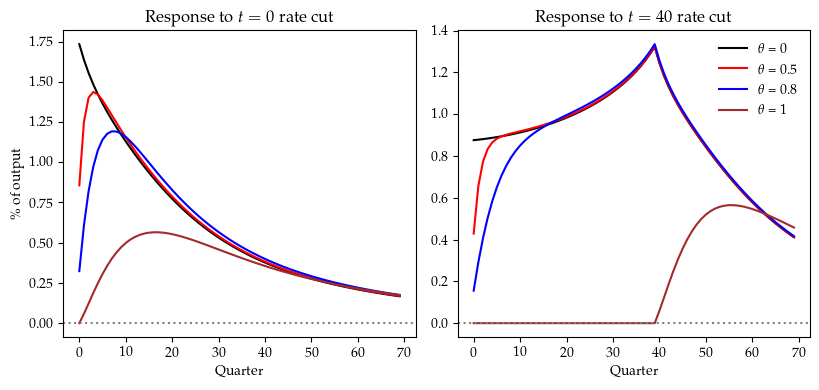

In [23]:
# Sticky expectations
thetas = [0, 0.5, 0.8, 1]
M_list = [manipulate_separable(M_ha, E_sticky_exp(theta)) for theta in thetas]
Mr_list = [manipulate_separable(Mr_ha, E_sticky_exp(theta)) for theta in thetas] #[Mr_ha] * len(M_list)
legend_list = ['$\\theta$ = '+str(theta) for theta in thetas]
plot_MP(Mr_list, M_list, filename='sticky_exp', legend_list=legend_list)

**Full vs. no sticky expectations.** Isolate the role of myopia in $M$ alone versus in both $M$ and $M^r$, against the FIRE benchmark.

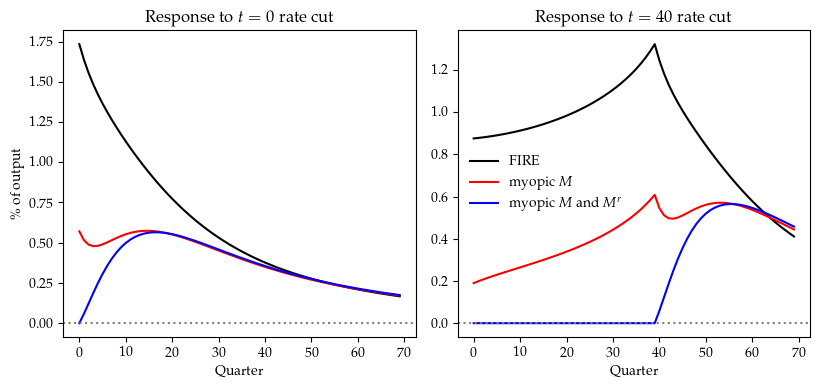

In [24]:
# Full vs no sticky expectations
thetas = [0, 1]
M_list = [manipulate_separable(M_ha, E_sticky_exp(theta)) for theta in thetas + [1]]
Mr_list = [Mr_ha] + [manipulate_separable(Mr_ha, E_sticky_exp(theta)) for theta in thetas] #[Mr_ha] * len(M_list)
legend_list = ['FIRE', 'myopic $M$', 'myopic $M$ and $M^r$']  # ['$\\theta$ = '+str(theta) for theta in thetas]
plot_MP(Mr_list, M_list, filename='full_sticky_exp', legend_list=legend_list)

**Dispersed information.** Sweep the signal precision ratio $\tau/\tau_\epsilon$ from $\infty$ (FIRE) to 0 (no information).

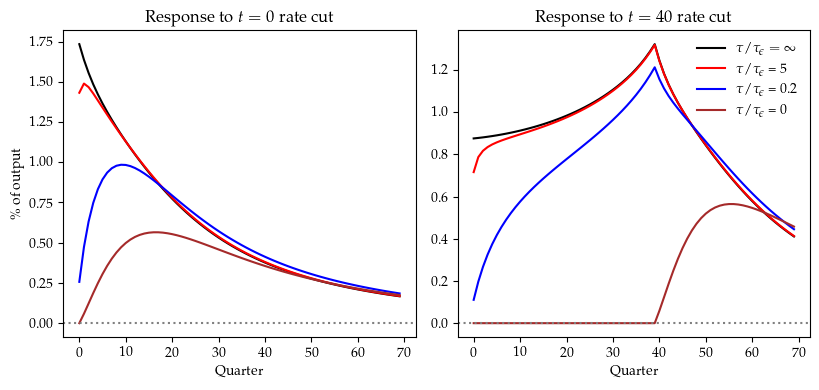

In [25]:
# Dispersed information
taus = [1e10, 5, 0.2, 0]  # constant for all j
M_list = [manipulate_separable(M_ha, E_dispersed_exog(np.ones(T)*tau)) for tau in taus]
Mr_list = [manipulate_separable(Mr_ha, E_dispersed_exog(np.ones(T)*tau)) for tau in taus] #[Mr_ha] * len(M_list)
legend_list = ['$\\tau / \\tau_\\epsilon = \\infty $'] + ['$\\tau / \\tau_\\epsilon $ = '+str(tau) for tau in taus[1:]]
plot_MP(Mr_list, M_list, filename='dispersed_info', legend_list=legend_list)

**Cognitive discounting.** Sweep $\theta$ from 1 (FIRE) toward 0 (myopia). This dampens forward guidance well but generates less of a hump than sticky expectations.

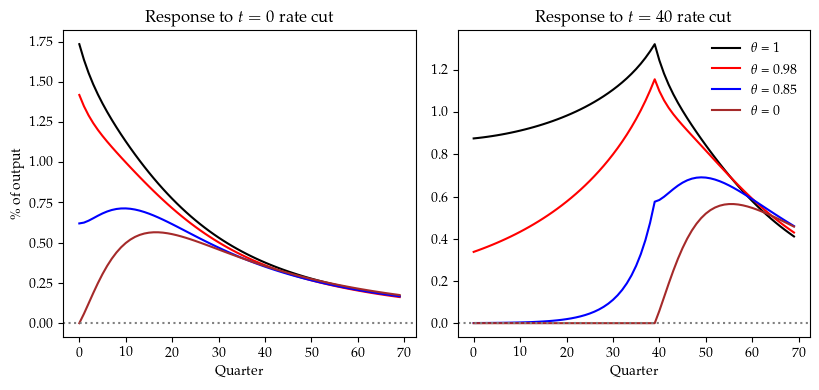

In [26]:
# Cognitive discounting
thetas = [1, 0.98, 0.85, 0]
M_list = [manipulate_separable(M_ha, E_cog_disc(theta)) for theta in thetas]
Mr_list = [manipulate_separable(Mr_ha, E_cog_disc(theta)) for theta in thetas] #[Mr_ha] * len(M_list)
legend_list = ['$\\theta$ = '+str(theta) for theta in thetas]
plot_MP(Mr_list, M_list, filename='cog_disc', legend_list=legend_list)

**Level-$k$ thinking.** Sweep the reasoning level $k$ from FIRE down to 1; higher $k$ approaches FIRE while $k=1$ is the myopic case.

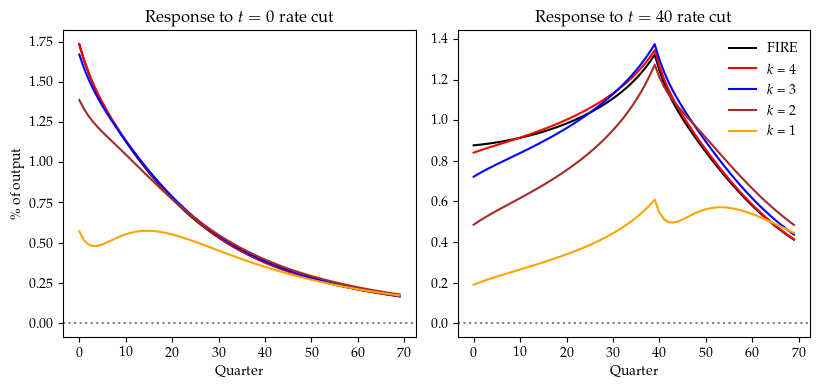

In [27]:
# Level k thinking
k_max = 4
M_list = [M_ha] + level_k(M_ha, k_max=k_max)
Mr_list = [Mr_ha] * len(M_list)
legend_list = ['FIRE'] + ['$k$ = '+str(k) for k in range(k_max, 0, -1)]
plot_MP(Mr_list, M_list, filename='level_k', legend_list=legend_list)